In [14]:
import matplotlib.pyplot as plt
import numpy as np

In [66]:
system_sizes = np.array([4, 8, 16, 32, 64, 128, 256, 512])
I0_ad_s = np.array([0.1027864045000415, 0.15848055423448892, 0.21712878234376143, 0.2753152188716519, 0.33144440632900085, 0.38465012849689273, 0.43447243296998883, 0.48074407166772304])
A_ad_s = np.array([0.08684806210189, 0.2937239784883905, 0.9834885193110438, 3.462006409300839, 12.945996946981577, 50.10131717876259, 200.2807615148392, 865.7989782959032])

fits_pure_rodeo_dict = {
    4: [-1.17559515, -2.11293442],
    8: [-0.87806029, -1.59726134],
    16: [-0.48759744, -1.29809816],
    32: [-0.24775083, -1.19262692],
    64: [-0.12483843, -1.07281272],
    128: [-0.05989677, -1.09026312],
    256: [-0.03056769, -1.05273972],
    512: [-0.01574746, -0.99522492]
}
success_probs_pure_rodeo = 1-I0_ad_s

fit_coefficients_hybrid_dict = {
    4: [-1.3430319, -4.77723841],
    8: [-0.85355529, -4.51138561],
    16: [-0.44556135, -4.81401089],
    32: [-0.22331143, -5.04485824],
    64: [-0.11273306, -5.13498613],
    128: [-0.04007379, -5.43394562],
    256: [-0.01627754, -5.5027642 ],
    512: [-0.00626452, -5.53740252]
}

success_probs_hybrid = [0.994992754538081, 0.9944200996260186, 0.9957562907492417, 0.9959631604979734, 0.9959131020247408, 0.996087041879362, 0.9961289255664071, 0.9985490442098839]

In [67]:
def adiabatic_tapered_fit(T, Li):
    return I0_ad_s[Li] / (1 + I0_ad_s[Li] / A_ad_s[Li] * np.power(T, 2))

def pure_rodeo_fit(T, Li):
    fc = fits_pure_rodeo_dict[system_sizes[Li]]
    return np.exp(fc[0] * T + fc[1])

def inverse_adiabatic_tapered_fit(I, Li):
    all_I = []
    for II in I:
        if II <= I0_ad_s[Li]:
            all_I.append(np.sqrt((I0_ad_s[Li]/II - 1)/(I0_ad_s[Li] / A_ad_s[Li])))
        else:
            all_I.append(np.nan)
    return np.array(all_I)

def inverse_rodeo_fit(I, Li):
    fc = fits_pure_rodeo_dict[system_sizes[Li]]
    return (np.log(I) - fc[1]) / fc[0]

In [115]:
def kappa_ell_ad(ell, I):
    nf = 2**(ell-1)-1
    tilde_I = I / nf
    summand = 0
    for i in range(2,ell+1):
        time_adiabatic = inverse_adiabatic_tapered_fit(tilde_I, i-2)
        prod = 1
        #for j in range(i, ell+1):
        #    prod *= success_probs_pure_rodeo[j-2]**(2**(ell-j))
        summand += time_adiabatic/prod
    return summand

def kappa_ell_rodeo(ell, I):
    nf = 2**(ell-1)-1
    tilde_I = I / nf
    summand = 0
    for i in range(2,ell+1):
        time_rodeo = inverse_rodeo_fit(tilde_I, i-2)
        prod = 1
        for j in range(i, ell+1):
            prod *= success_probs_pure_rodeo[j-2]**(2**(ell-j))
        summand += time_rodeo/prod
    return summand

def kappa_ell_hybrid(ell, I):
    nf = 2**(ell-1)-1
    tilde_I = I / nf
    summand = 0
    for i in range(2,ell+1):
        time_adiabatic = 0.84 * 2**i + 1.19
        time_rodeo = inverse_rodeo_fit(tilde_I, i-2)
        time_hybrid = time_adiabatic + time_rodeo
        prod = 1
        for j in range(i, ell+1):
            prod *= success_probs_hybrid[j-2]**(2**(ell-j))
        summand += time_hybrid/prod
    return summand

def both(kappa):
    return kappa * (3*kappa - 2) / (2*kappa -1 )

def kappa_ell_rodeo_both(ell, I):
    if ell == 1:
        return 0
    nf = 2**(ell-1)-1
    tilde_I = I / nf

    kappa_val = kappa_ell_rodeo_both(ell-1, I)
    time_rodeo = inverse_rodeo_fit(tilde_I, ell-2)
    success_prob = success_probs_pure_rodeo[ell-2]
    return (time_rodeo + both(kappa_val))/success_prob
    
def kappa_ell_hybrid_both(ell, I):
    if ell == 1:
        return 0
    nf = 2**(ell-1)-1
    tilde_I = I / nf

    kappa_val = kappa_ell_hybrid_both(ell-1, I)
    time_adiabatic = 0.84 * 2**ell + 1.19
    time_rodeo = inverse_rodeo_fit(tilde_I, ell-2)
    time_hybrid = time_adiabatic + time_rodeo
    success_prob = success_probs_hybrid[ell-2]
    return (time_hybrid + both(kappa_val))/success_prob


In [116]:
%matplotlib tk
lw = 2
colors = plt.cm.viridis(np.linspace(0, 1, len(system_sizes)))
I_eval = np.logspace(0, -7, 100)
ell_s = [2,3,4,5,6,7,8,9]
for ell in ell_s:
    kappa_evaled_ad = kappa_ell_ad(ell, I_eval)
    plt.plot(I_eval, kappa_evaled_ad, color=colors[ell-2], lw=lw)
    kappa_evaled_rodeo = kappa_ell_rodeo_both(ell, I_eval)
    plt.plot(I_eval, kappa_evaled_rodeo, linestyle='--', color=colors[ell-2], lw=lw)
    kappa_evaled_hybrid = kappa_ell_hybrid_both(ell, I_eval)
    plt.plot(I_eval, kappa_evaled_hybrid, linestyle=':', color=colors[ell-2], lw=lw)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\mathcal I$")
plt.ylabel(r"$\kappa _\ell$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1e-10, 1)

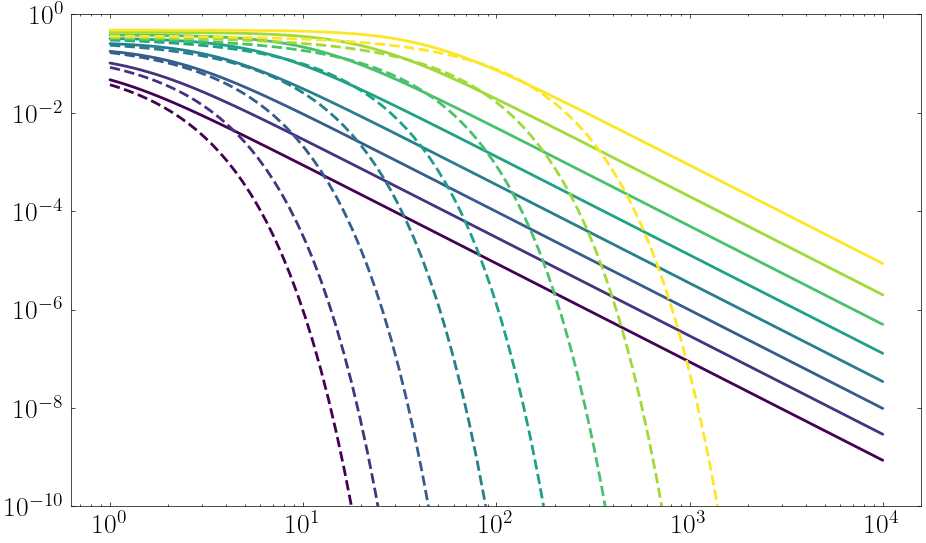

In [70]:
colors = plt.cm.viridis(np.linspace(0, 1, len(system_sizes)))
times_to_plot = np.logspace(0, 4, 100)
for Li, L in enumerate(system_sizes):
    plt.plot(times_to_plot, adiabatic_tapered_fit(times_to_plot, Li), label=f"L={L}", color=colors[Li], lw=2)
    plt.plot(times_to_plot, pure_rodeo_fit(times_to_plot, Li), label=f"L={L} (Pure Rodeo)", color=colors[Li], lw=2, linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.ylim(bottom = 1e-10,top=1)

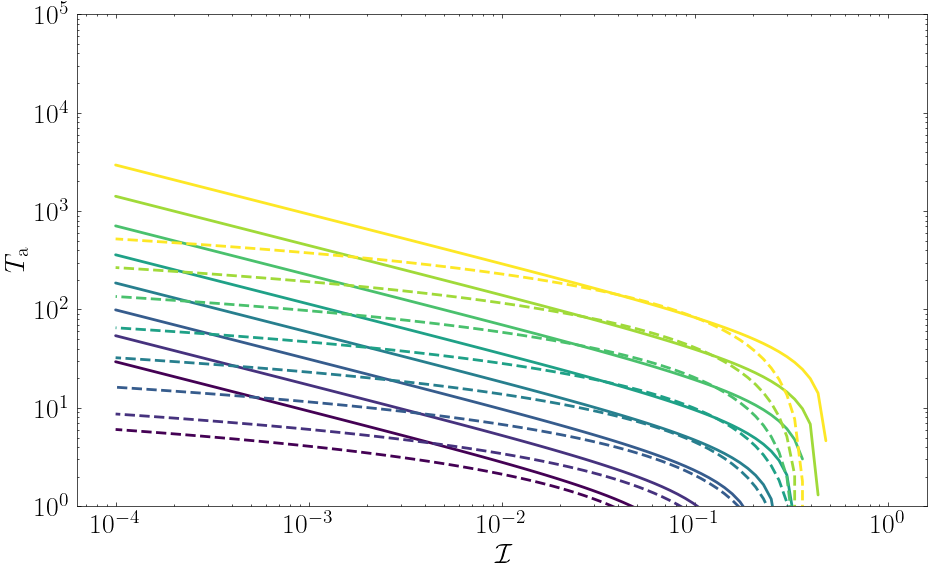

In [31]:
I_s = np.logspace(0, -4, 100)
for Li, L in enumerate(system_sizes):
    plt.plot(I_s, inverse_adiabatic_tapered_fit(I_s, Li), label=f"L={L}", color=colors[Li], lw=2)
for Li, L in enumerate(system_sizes):
    plt.plot(I_s, inverse_rodeo_fit(I_s, Li), label=f"L={L} (Pure Rodeo)", color=colors[Li], lw=2, linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\mathcal I$")
plt.ylabel(r"$T_{\mathrm a}$")
plt.ylim(bottom=1, top=1e5)
plt.show()

/tmp/ipykernel_104397/2439376597.py:51: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, boundaries=bounds)


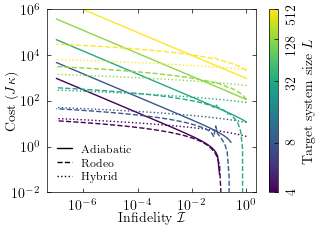

In [122]:
%matplotlib inline
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator
plt.style.use('~/.config/matplotlib/paper.mplstyle')

plt.figure(figsize=(3.375, 2.5))
lw = 1
#ell_s = np.array([2,3,4,5,6,7,8,9])
ell_s = np.array([2,3,5,7,9])

I_eval = np.logspace(0, -7, 100)

# -----------------------------
# Colormap with log scaling in ell
# -----------------------------
#norm = LogNorm(vmin=ell_s.min(), vmax=ell_s.max())
bounds = np.logspace(np.log10(ell_s.min()), np.log10(ell_s.max()), 256)
norm = LogNorm(vmin=ell_s.min(), vmax=ell_s.max())

cmap = cm.viridis

# -----------------------------
# Plot
# -----------------------------
for ell in ell_s:
    color = cmap(norm(ell))

    plt.plot(I_eval, kappa_ell_ad(ell, I_eval),
             color=color, lw=lw)

    plt.plot(I_eval, kappa_ell_rodeo_both(ell, I_eval),
             linestyle='--', color=color, lw=lw)

    plt.plot(I_eval, kappa_ell_hybrid_both(ell, I_eval),
             linestyle=':', color=color, lw=lw)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Infidelity $\mathcal I$", labelpad=0)
plt.ylabel(r"Cost $(J\kappa)$", labelpad=-5)

# -----------------------------
# Colorbar (log in ell)
# -----------------------------
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

#cbar = plt.colorbar(sm)
cbar = plt.colorbar(sm, boundaries=bounds)

# Choose sparse ticks to avoid clutter
tick_ells = ell_s #np.array([2, 5, 9])
cbar.set_ticks(tick_ells)

cbar.ax.yaxis.set_major_locator(FixedLocator(tick_ells))
cbar.ax.yaxis.set_minor_locator(NullLocator())

# Label as L = 2^ell
cbar.set_ticklabels([rf"${{{int(2**ell)}}}$" for ell in tick_ells])

# Rotate tick labels
cbar.ax.set_yticklabels(
    [rf"${{{int(2**ell)}}}$" for ell in tick_ells],
    rotation=90
)

# -----------------------------
# Fake legend for methods
# -----------------------------
legend_lines = [
    Line2D([0], [0], color='black', lw=lw, linestyle='-'),
    Line2D([0], [0], color='black', lw=lw, linestyle='--'),
    Line2D([0], [0], color='black', lw=lw, linestyle=':')
]

legend_labels = ["Adiabatic", "Rodeo", "Hybrid"]
cbar.set_label(r"Target system size $L$")

plt.legend(legend_lines, legend_labels, fontsize=8, loc="lower left")

plt.tight_layout()
plt.ylim(bottom=1e-2,top=1e6)

plt.savefig("figures/combined_costs.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_104397/3860868756.py:79: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, boundaries=edges, ticks=ell_s)


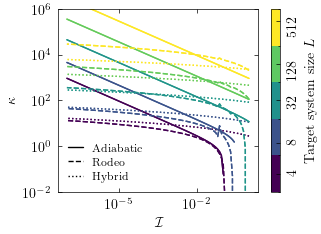

In [121]:
%matplotlib inline
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator
plt.style.use('~/.config/matplotlib/paper.mplstyle')

plt.figure(figsize=(3.375, 2.5))
lw = 1
#ell_s = np.array([2,3,4,5,6,7,8,9])
ell_s = np.array([2,3,5,7,9])

I_eval = np.logspace(0, -7, 100)

# -----------------------------
# Colormap with log scaling in ell
# -----------------------------
norm = LogNorm(vmin=ell_s.min(), vmax=ell_s.max())
cmap = cm.viridis

# -----------------------------
# Plot
# -----------------------------
for ell in ell_s:
    color = cmap(norm(ell))

    plt.plot(I_eval, kappa_ell_ad(ell, I_eval),
             color=color, lw=lw)

    plt.plot(I_eval, kappa_ell_rodeo_both(ell, I_eval),
             linestyle='--', color=color, lw=lw)

    plt.plot(I_eval, kappa_ell_hybrid_both(ell, I_eval),
             linestyle=':', color=color, lw=lw)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$\mathcal I$")
plt.ylabel(r"$\kappa$")

from matplotlib.colors import BoundaryNorm

# -----------------------------
# Discrete colormap in ell
# -----------------------------
ell_s = np.array([2,3,5,7,9])  # already defined above

# Create bin edges midway between ell values
edges = np.concatenate((
    [ell_s[0] - 0.5],
    0.5 * (ell_s[:-1] + ell_s[1:]),
    [ell_s[-1] + 0.5]
))

cmap = cm.get_cmap('viridis', len(ell_s))  # discrete viridis
norm = BoundaryNorm(edges, cmap.N)

# -----------------------------
# Plot (same loop, just uses new norm)
# -----------------------------
for ell in ell_s:
    color = cmap(norm(ell))

    plt.plot(I_eval, kappa_ell_ad(ell, I_eval),
             color=color, lw=lw)

    plt.plot(I_eval, kappa_ell_rodeo_both(ell, I_eval),
             linestyle='--', color=color, lw=lw)
    
    plt.plot(I_eval, kappa_ell_hybrid_both(ell, I_eval),
             linestyle=':', color=color, lw=lw)

# -----------------------------
# Colorbar (DISCRETE)
# -----------------------------
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, boundaries=edges, ticks=ell_s)

# Label ticks as L = 2^ell (numeric)
cbar.ax.set_yticklabels(
    [rf"${int(2**ell)}$" for ell in ell_s],
    rotation=90
)

cbar.set_label(r"Target system size $L$")

# -----------------------------
# Fake legend for methods
# -----------------------------
legend_lines = [
    Line2D([0], [0], color='black', lw=lw, linestyle='-'),
    Line2D([0], [0], color='black', lw=lw, linestyle='--'),
    Line2D([0], [0], color='black', lw=lw, linestyle=':')
]

legend_labels = ["Adiabatic", "Rodeo", "Hybrid"]

plt.legend(legend_lines, legend_labels, fontsize=8, loc="lower left")

plt.tight_layout()
plt.ylim(bottom=1e-2,top=1e6)

plt.savefig("figures/combined_costs.pdf", bbox_inches='tight')
plt.show()